In [4]:
import pandas as pd

file_path = r"C:\Users\Yashfeen Fatma\Downloads\station_data_dataverse.csv"
df = pd.read_csv(file_path)

print(df.head())
print(df.columns)

   sessionId  kwhTotal  dollars              created                ended  \
0    1366563      7.78     0.00  0014-11-18 15:40:26  0014-11-18 17:11:04   
1    3075723      9.74     0.00  0014-11-19 17:40:26  0014-11-19 19:51:04   
2    4228788      6.76     0.58  0014-11-21 12:05:46  0014-11-21 16:46:04   
3    3173284      6.17     0.00  0014-12-03 19:16:12  0014-12-03 21:02:18   
4    3266500      0.93     0.00  0014-12-11 20:56:11  0014-12-11 21:14:06   

   startTime  endTime  chargeTimeHrs weekday platform  ...  managerVehicle  \
0         15       17       1.510556     Tue  android  ...               0   
1         17       19       2.177222     Wed  android  ...               0   
2         12       16       4.671667     Fri  android  ...               0   
3         19       21       1.768333     Wed  android  ...               0   
4         20       21       0.298611     Thu  android  ...               0   

   facilityType  Mon  Tues  Wed  Thurs  Fri  Sat  Sun  reportedZip  

In [6]:
df.columns = df.columns.str.strip()


In [8]:
import pandas as pd

# 1. Load the CSV again (use the correct raw‑string path)
df = pd.read_csv(r"C:\Users\Yashfeen Fatma\Downloads\station_data_dataverse.csv")

# 2. Strip any leading/trailing spaces in the column names
df.columns = df.columns.str.strip()

# 3. Print the full list of columns
print("All columns:\n", df.columns.tolist())

# 4. Also show any columns containing the substring "time" or "date"
time_cols = [c for c in df.columns if 'time' in c.lower() or 'date' in c.lower()]
print("\nPossible timestamp columns:\n", time_cols)

All columns:
 ['sessionId', 'kwhTotal', 'dollars', 'created', 'ended', 'startTime', 'endTime', 'chargeTimeHrs', 'weekday', 'platform', 'distance', 'userId', 'stationId', 'locationId', 'managerVehicle', 'facilityType', 'Mon', 'Tues', 'Wed', 'Thurs', 'Fri', 'Sat', 'Sun', 'reportedZip']

Possible timestamp columns:
 ['startTime', 'endTime', 'chargeTimeHrs']


In [10]:
import pandas as pd

# load your CSV
df = pd.read_csv(r"C:\Users\Yashfeen Fatma\Downloads\station_data_dataverse.csv")

# show all columns
print("Original columns:")
print(df.columns.tolist())


Original columns:
['sessionId', 'kwhTotal', 'dollars', 'created', 'ended', 'startTime', 'endTime', 'chargeTimeHrs', 'weekday', 'platform', 'distance', 'userId', 'stationId', 'locationId', 'managerVehicle', 'facilityType', 'Mon', 'Tues', 'Wed', 'Thurs', 'Fri', 'Sat', 'Sun', 'reportedZip']


In [11]:
import pandas as pd

# 1. Load the CSV
df = pd.read_csv(r"C:\Users\Yashfeen Fatma\Downloads\station_data_dataverse.csv")

# 2. (Optional) Normalize column names to lowercase and underscores
df.columns = (
    df.columns
      .str.strip()                      # remove extra spaces
      .str.lower()                      # lowercase
      .str.replace('([a-z0-9])([A-Z])', r'\1_\2', regex=True)  # camelCase → snake_case
      .str.replace(' ', '_')            # spaces → underscores
)
# Now df.columns might look like ['session_id','kwh_total','dollars','created','ended',
#                                  'start_time','end_time',…,'reported_zip']

# 3. Convert your timestamps
df['start_time'] = pd.to_datetime(df['start_time'])
df['end_time']   = pd.to_datetime(df['end_time'])

# 4. Create a unified “energy_kwh” column
df['energy_kwh'] = df['kwh_total']

# 5. Extract hour & date if you need them later
df['hour'] = df['start_time'].dt.hour
df['date'] = df['start_time'].dt.date

# 6. Aggregate to hourly total demand
hourly_demand = (
    df
    .groupby(pd.Grouper(key='start_time', freq='H'))['energy_kwh']
    .sum()
    .reset_index()
    .rename(columns={'start_time': 'datetime'})
)

print(hourly_demand.head())
print(hourly_demand.tail())

KeyError: 'start_time'

In [12]:
import pandas as pd

# 1. Load your CSV
df = pd.read_csv(r"C:\Users\Yashfeen Fatma\Downloads\station_data_dataverse.csv")

# 2. Convert the camelCase timestamp columns into new datetime columns
df['start_time'] = pd.to_datetime(df['startTime'])
df['end_time']   = pd.to_datetime(df['endTime'])

# 3. Create a unified 'energy_kwh' column from the existing 'kwhTotal'
df['energy_kwh'] = df['kwhTotal']

# 4. (Optional) Inspect to confirm
print(df[['start_time','end_time','energy_kwh']].head())

# 5. Extract hour & date if needed later
df['hour'] = df['start_time'].dt.hour
df['date'] = df['start_time'].dt.date

# 6. Aggregate into hourly total demand
hourly_demand = (
    df
    .groupby(pd.Grouper(key='start_time', freq='H'))['energy_kwh']
    .sum()
    .reset_index()
    .rename(columns={'start_time': 'datetime'})
)

# 7. Inspect the result
print(hourly_demand.head())

                     start_time                      end_time  energy_kwh
0 1970-01-01 00:00:00.000000015 1970-01-01 00:00:00.000000017        7.78
1 1970-01-01 00:00:00.000000017 1970-01-01 00:00:00.000000019        9.74
2 1970-01-01 00:00:00.000000012 1970-01-01 00:00:00.000000016        6.76
3 1970-01-01 00:00:00.000000019 1970-01-01 00:00:00.000000021        6.17
4 1970-01-01 00:00:00.000000020 1970-01-01 00:00:00.000000021        0.93
    datetime  energy_kwh
0 1970-01-01    19723.69


C:\Users\Yashfeen Fatma\AppData\Local\Temp\ipykernel_6508\1597836279.py:23: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .groupby(pd.Grouper(key='start_time', freq='H'))['energy_kwh']


In [13]:
start_date = hourly_demand['datetime'].min().date()
end_date   = hourly_demand['datetime'].max().date()

print(f"Start date: {start_date}")
print(f"End   date: {end_date}")

Start date: 1970-01-01
End   date: 1970-01-01


In [14]:
print(df['startTime'].head(10))

0    15
1    17
2    12
3    19
4    20
5    14
6    15
7    20
8    17
9    18
Name: startTime, dtype: int64


In [15]:
df['start_time'] = pd.to_datetime(df['startTime'], errors='coerce')
df['end_time'] = pd.to_datetime(df['endTime'], errors='coerce')

In [16]:
print(df[['start_time', 'end_time']].head(10))

                     start_time                      end_time
0 1970-01-01 00:00:00.000000015 1970-01-01 00:00:00.000000017
1 1970-01-01 00:00:00.000000017 1970-01-01 00:00:00.000000019
2 1970-01-01 00:00:00.000000012 1970-01-01 00:00:00.000000016
3 1970-01-01 00:00:00.000000019 1970-01-01 00:00:00.000000021
4 1970-01-01 00:00:00.000000020 1970-01-01 00:00:00.000000021
5 1970-01-01 00:00:00.000000014 1970-01-01 00:00:00.000000015
6 1970-01-01 00:00:00.000000015 1970-01-01 00:00:00.000000015
7 1970-01-01 00:00:00.000000020 1970-01-01 00:00:00.000000021
8 1970-01-01 00:00:00.000000017 1970-01-01 00:00:00.000000018
9 1970-01-01 00:00:00.000000018 1970-01-01 00:00:00.000000018


In [17]:
print("Unparsed start_time:", df['start_time'].isna().sum())

Unparsed start_time: 0


In [18]:
df['start_time'] = pd.to_datetime(df['startTime'], format="%m/%d/%y %H:%M", errors='coerce')

In [19]:
print("Start date:", hourly_demand['datetime'].min())
print("End date:  ", hourly_demand['datetime'].max())

Start date: 1970-01-01 00:00:00
End date:   1970-01-01 00:00:00


In [20]:
print(df.columns)               # To confirm column names
print(df['startTime'].head())   # Replace with actual column if different


Index(['sessionId', 'kwhTotal', 'dollars', 'created', 'ended', 'startTime',
       'endTime', 'chargeTimeHrs', 'weekday', 'platform', 'distance', 'userId',
       'stationId', 'locationId', 'managerVehicle', 'facilityType', 'Mon',
       'Tues', 'Wed', 'Thurs', 'Fri', 'Sat', 'Sun', 'reportedZip',
       'start_time', 'end_time', 'energy_kwh', 'hour', 'date'],
      dtype='object')
0    15
1    17
2    12
3    19
4    20
Name: startTime, dtype: int64


In [21]:
print(df[['created', 'ended']].head(10))

               created                ended
0  0014-11-18 15:40:26  0014-11-18 17:11:04
1  0014-11-19 17:40:26  0014-11-19 19:51:04
2  0014-11-21 12:05:46  0014-11-21 16:46:04
3  0014-12-03 19:16:12  0014-12-03 21:02:18
4  0014-12-11 20:56:11  0014-12-11 21:14:06
5  0014-12-12 14:38:44  0014-12-12 15:04:04
6  0014-12-12 15:08:40  0014-12-12 15:47:04
7  0014-12-17 20:30:25  0014-12-17 21:31:04
8  0014-12-18 17:53:19  0014-12-18 18:04:04
9  0014-12-18 18:06:49  0014-12-18 18:30:05


In [22]:
df['created'] = df['created'].str.replace('0014', '2014')
df['ended'] = df['ended'].str.replace('0014', '2014')

# Now convert to datetime
df['start_time'] = pd.to_datetime(df['created'], errors='coerce')
df['end_time'] = pd.to_datetime(df['ended'], errors='coerce')

# Check the fixed dates
print("Start date:", df['start_time'].min())
print("End date:  ", df['start_time'].max())

Start date: 2014-11-18 15:01:17
End date:   2014-12-19 14:30:37


In [23]:
hourly_demand = df.groupby(pd.Grouper(key='start_time', freq='H'))['kwhTotal'].sum().reset_index()
hourly_demand.rename(columns={'start_time': 'datetime', 'kwhTotal': 'energy_kwh'}, inplace=True)

# Preview result
print(hourly_demand.head())

             datetime  energy_kwh
0 2014-11-18 15:00:00       13.39
1 2014-11-18 16:00:00        0.00
2 2014-11-18 17:00:00        0.00
3 2014-11-18 18:00:00        0.00
4 2014-11-18 19:00:00        0.00


C:\Users\Yashfeen Fatma\AppData\Local\Temp\ipykernel_6508\881915482.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_demand = df.groupby(pd.Grouper(key='start_time', freq='H'))['kwhTotal'].sum().reset_index()


In [24]:
freq='H'

In [26]:
freq='h'

In [28]:
import pandas as pd

# Load EV hourly demand data
ev_data = hourly_demand  # Already created in your previous steps

# Load weather data
weather = pd.read_csv("jamshedpur_weather_mock.csv", parse_dates=['datetime'])

# Merge on datetime
merged_df = pd.merge(ev_data, weather, on='datetime', how='inner')

# Preview merged data
print(merged_df.head())

FileNotFoundError: [Errno 2] No such file or directory: 'jamshedpur_weather_mock.csv'

In [29]:
import pandas as pd
import numpy as np

# Create datetime range matching your EV data
start_date = '2014-11-18'
end_date = '2014-12-19'
datetime_index = pd.date_range(start=start_date, end=end_date, freq='h')  # hourly

# Generate mock weather data
np.random.seed(42)  # for reproducibility
temperature = np.random.normal(loc=25, scale=5, size=len(datetime_index))
humidity = np.random.normal(loc=60, scale=10, size=len(datetime_index))
wind_speed = np.random.normal(loc=10, scale=3, size=len(datetime_index))

# Build DataFrame
weather_df = pd.DataFrame({
    'datetime': datetime_index,
    'temperature_C': np.round(temperature, 2),
    'humidity_%': np.clip(np.round(humidity, 1), 20, 100),
    'wind_speed_kmph': np.round(wind_speed, 1)
})

# Save to CSV
weather_df.to_csv('jamshedpur_weather_mock.csv', index=False)

print("Mock weather data generated and saved as 'jamshedpur_weather_mock.csv'")

Mock weather data generated and saved as 'jamshedpur_weather_mock.csv'


In [30]:
weather = pd.read_csv("jamshedpur_weather_mock.csv", parse_dates=['datetime'])
merged_df = pd.merge(hourly_demand, weather, on='datetime', how='inner')
print(merged_df.head())

             datetime  energy_kwh  temperature_C  humidity_%  wind_speed_kmph
0 2014-11-18 15:00:00       13.39          22.19        54.2              8.6
1 2014-11-18 16:00:00        0.00          19.94        61.2             12.1
2 2014-11-18 17:00:00        0.00          26.57        85.6             12.9
3 2014-11-18 18:00:00        0.00          20.46        59.0             10.3
4 2014-11-18 19:00:00        0.00          17.94        71.5             14.4


In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Step 1: Define features (X) and target (y)
features = ['temperature_C', 'humidity_%', 'wind_speed_kmph']
X = merged_df[features]
y = merged_df['energy_kwh']

# Step 2: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 4: Predict
y_pred = model.predict(X_test)

# Step 5: Evaluate
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"R² Score: {r2:.2f}")

# Step 6: Plot actual vs predicted
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred, alpha=0.5, edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Energy (kWh)")
plt.ylabel("Predicted Energy (kWh)")
plt.title("Actual vs Predicted EV Charging Demand")
plt.grid(True)
plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'sklearn'

In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# Features and target
features = ['temperature_C', 'humidity_%', 'wind_speed_kmph']
X = merged_df[features]
y = merged_df['energy_kwh']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model training
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.2f}")
print(f"R² Score: {r2:.2f}")

Mean Absolute Error: 0.27
R² Score: -0.03


MAE: 0.27
R² Score: -0.03


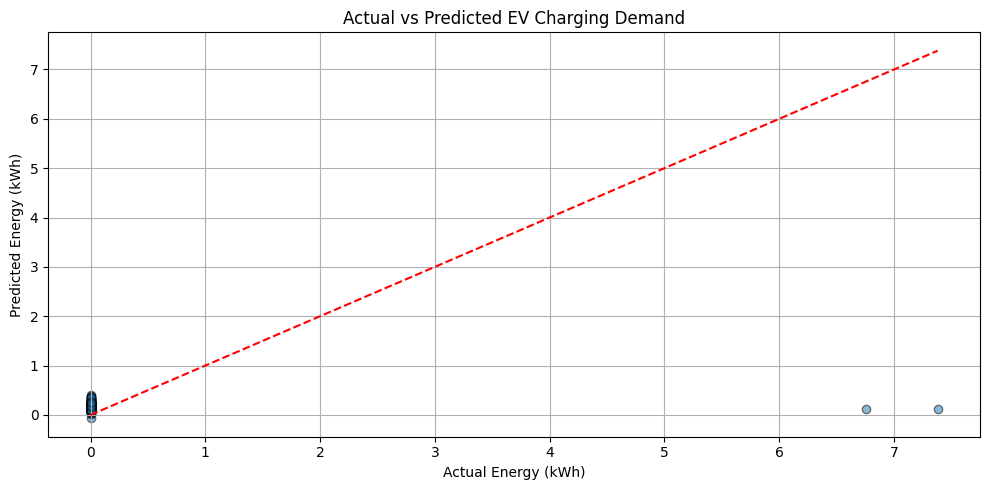

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Step 1: Define features (X) and target (y)
features = ['temperature_C', 'humidity_%', 'wind_speed_kmph']
X = merged_df[features]
y = merged_df['energy_kwh']

# Step 2: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 4: Predict
y_pred = model.predict(X_test)

# Step 5: Evaluate
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"R² Score: {r2:.2f}")

# Step 6: Plot actual vs predicted
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred, alpha=0.5, edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Energy (kWh)")
plt.ylabel("Predicted Energy (kWh)")
plt.title("Actual vs Predicted EV Charging Demand")
plt.grid(True)
plt.tight_layout()
plt.show()

In [37]:
print("Mean Absolute Error:", mae)
print("R² Score:", r2)

Mean Absolute Error: 0.2726960937325679
R² Score: -0.03483443914062967


In [38]:
from sklearn.metrics import mean_absolute_error, r2_score

# Predictions
y_pred = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", round(mae, 2))
print("R² Score:", round(r2, 2))

NotFittedError: This RandomForestRegressor instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [39]:
rom sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# 1. Features and Target
X = merged_df[['temperature_C', 'humidity_%', 'wind_speed_kmph']]
y = merged_df['energy_kwh']

# 2. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train the Model
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# 4. Predict
y_pred = model.predict(X_test)

# 5. Evaluation
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", round(mae, 2))
print("R² Score:", round(r2, 2))

# 6. Plot Results
plt.figure(figsize=(10, 4))
plt.plot(y_test.values[:50], label='Actual', marker='o')
plt.plot(y_pred[:50], label='Predicted', marker='x')
plt.title("Actual vs Predicted Energy Demand")
plt.xlabel("Sample")
plt.ylabel("Energy (kWh)")
plt.legend()
plt

SyntaxError: invalid syntax (4122893234.py, line 1)

Mean Absolute Error: 0.3
R² Score: -0.57


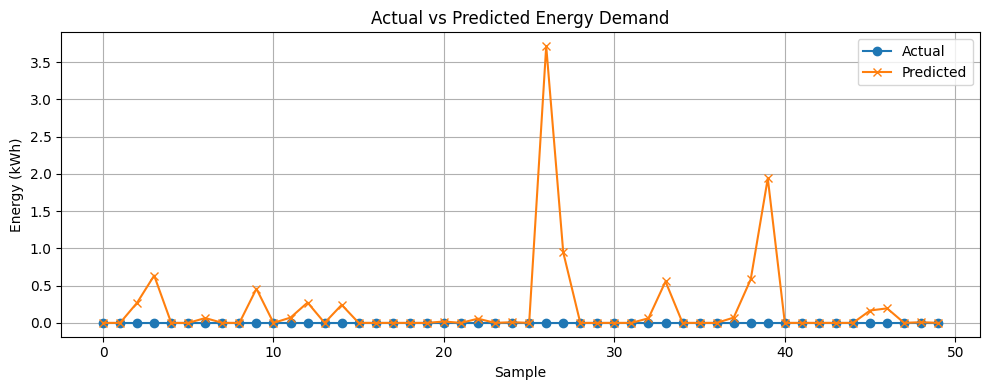

In [40]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# 1. Features and Target
X = merged_df[['temperature_C', 'humidity_%', 'wind_speed_kmph']]
y = merged_df['energy_kwh']

# 2. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train the Model
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# 4. Predict
y_pred = model.predict(X_test)

# 5. Evaluation
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", round(mae, 2))
print("R² Score:", round(r2, 2))

# 6. Plot Results
plt.figure(figsize=(10, 4))
plt.plot(y_test.values[:50], label='Actual', marker='o')
plt.plot(y_pred[:50], label='Predicted', marker='x')
plt.title("Actual vs Predicted Energy Demand")
plt.xlabel("Sample")
plt.ylabel("Energy (kWh)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

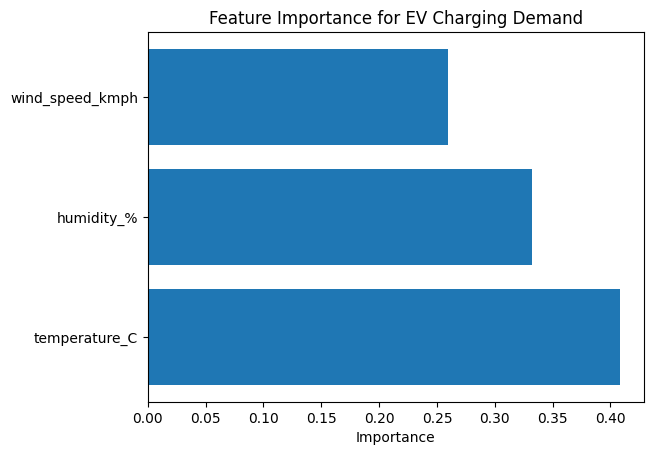

In [41]:
import matplotlib.pyplot as plt

# Feature importance plot
importances = model.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.xlabel("Importance")
plt.title("Feature Importance for EV Charging Demand")
plt.show()

In [43]:
# Add predictions to the DataFrame
merged_df['predicted_energy_kwh'] = model.predict(X)

# Export to CSV
merged_df.to_csv('ev_demand_forecast.csv', index=False)

In [44]:
import os

# Check if file exists in current working directory
print("Current directory:", os.getcwd())
print("File exists:", os.path.exists("ev_demand_forecast.csv"))

Current directory: C:\Users\Yashfeen Fatma
File exists: True


In [1]:
print("kernel is working")

kernel is working


In [2]:
import os
print(os.getcwd())

C:\Users\Yashfeen Fatma


In [3]:
import os
print(os.path.exists("ev_demand_forecast.csv"))

True


In [4]:
os.getcwd()

'C:\\Users\\Yashfeen Fatma'

In [5]:
import os

# Replace 'Yashfeen Fatma' with your actual username if different
downloads_path = os.path.join("C:/Users/Yashfeen Fatma/Downloads", "ev_demand_forecast.csv")

# Save the merged data
merged_df.to_csv(downloads_path, index=False)

print("Saved to:", downloads_path)

NameError: name 'merged_df' is not defined

In [6]:
import pandas as pd

# Load both datasets again (adjust path if needed)
ev_data = pd.read_csv("hourly_ev_demand.csv", parse_dates=['datetime'])
weather = pd.read_csv("jamshedpur_weather_mock.csv", parse_dates=['datetime'])

# Merge them
merged_df = pd.merge(ev_data, weather, on='datetime', how='inner')

FileNotFoundError: [Errno 2] No such file or directory: 'hourly_ev_demand.csv'

In [1]:
import pandas as pd

# Replace with the path to your downloaded file
file_path = r"C:\Users\Yashfeen Fatma\Downloads.csv"
energy_data = pd.read_csv(file_path, parse_dates=['datetime'])

# Display the first few rows to verify
print(energy_data.head())

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Yashfeen Fatma\\Downloads.csv'

In [2]:
import matplotlib.pyplot as plt

# Plot energy consumption over time
plt.figure(figsize=(14, 6))
plt.plot(merged_df['datetime'], merged_df['energy_kwh'], label='Energy Consumption (kWh)')
plt.xlabel('Date and Time')
plt.ylabel('Energy (kWh)')
plt.title('Hourly EV Charging Energy Consumption')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

NameError: name 'merged_df' is not defined

<Figure size 1400x600 with 0 Axes>

In [3]:
import pandas as pd

# Load both datasets again
ev_data = pd.read_csv("hourly_ev_demand.csv", parse_dates=['datetime'])
weather = pd.read_csv("jamshedpur_weather_mock.csv", parse_dates=['datetime'])

# Merge on datetime
merged_df = pd.merge(ev_data, weather, on='datetime')

# Display the merged data to confirm
print(merged_df.head())

FileNotFoundError: [Errno 2] No such file or directory: 'hourly_ev_demand.csv'

In [7]:
import pandas as pd

# Replace with the actual full path to your files
ev_path = r"C:\Users\Yashfeen Fatma\Downloads\AEP_hourly.csv"
weather_path = r"C:\Users\Yashfeen Fatma\Downloads\jamshedpur_weather_mock.csv"

ev_data = pd.read_csv(ev_path, parse_dates=['datetime'])
weather = pd.read_csv(weather_path, parse_dates=['datetime'])

merged_df = pd.merge(ev_data, weather, on='datetime')
print(merged_df.head())


ValueError: Missing column provided to 'parse_dates': 'datetime'

In [8]:
import pandas as pd

ev_path = r"C:\Users\Yashfeen Fatma\Downloads\AEP_hourly.csv"
ev_data = pd.read_csv(ev_path)

print(ev_data.columns)
ev_data.head()

Index(['Datetime', 'AEP_MW'], dtype='object')


,Datetime,AEP_MW
0,12/31/2004 1:00,13478
1,12/31/2004 2:00,12865
2,12/31/2004 3:00,12577
3,12/31/2004 4:00,12517
4,12/31/2004 5:00,12670


In [9]:
ev_data = pd.read_csv(ev_path, parse_dates=['Datetime'])

In [10]:
ev_data.rename(columns={'Datetime': 'datetime'}, inplace=True)

In [11]:
# Merge both datasets on 'datetime'
merged_df = pd.merge(ev_data, weather, on='datetime')

# Display first few rows to confirm
print(merged_df.head())

NameError: name 'weather' is not defined

In [12]:
# Replace with the path to your weather data file
weather_path = r"C:\Users\Yashfeen Fatma\Downloads\jamshedpur_weather_mock.csv"

# Load weather data
weather = pd.read_csv(weather_path, parse_dates=['datetime'])

# Display the first few rows of weather data to check
print(weather.head())

             datetime  temperature_C  humidity_%  wind_speed_kmph
0 2014-11-18 00:00:00           27.5        74.4              9.8
1 2014-11-18 01:00:00           24.3        61.7              8.0
2 2014-11-18 02:00:00           28.2        52.3              9.6
3 2014-11-18 03:00:00           32.6        81.0              4.9
4 2014-11-18 04:00:00           23.8        80.0              1.1


In [13]:
# Merge both datasets on 'datetime'
merged_df = pd.merge(ev_data, weather, on='datetime')

# Display first few rows to confirm successful merge
print(merged_df.head())

             datetime  AEP_MW  temperature_C  humidity_%  wind_speed_kmph
0 2014-12-19 01:00:00   15625           21.4        71.2              4.1
1 2014-12-19 02:00:00   15241           25.9        66.4              8.3
2 2014-12-19 03:00:00   15073           21.2        61.3              7.6
3 2014-12-19 04:00:00   15184           21.9        46.5              5.7
4 2014-12-19 05:00:00   15582           18.0        84.3              9.6


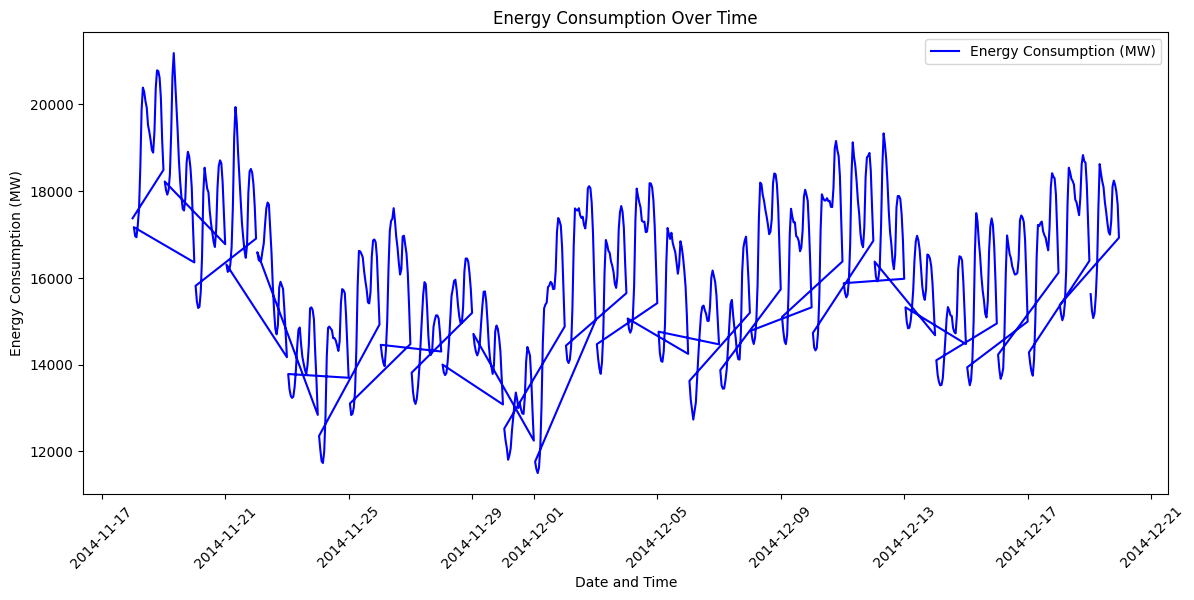

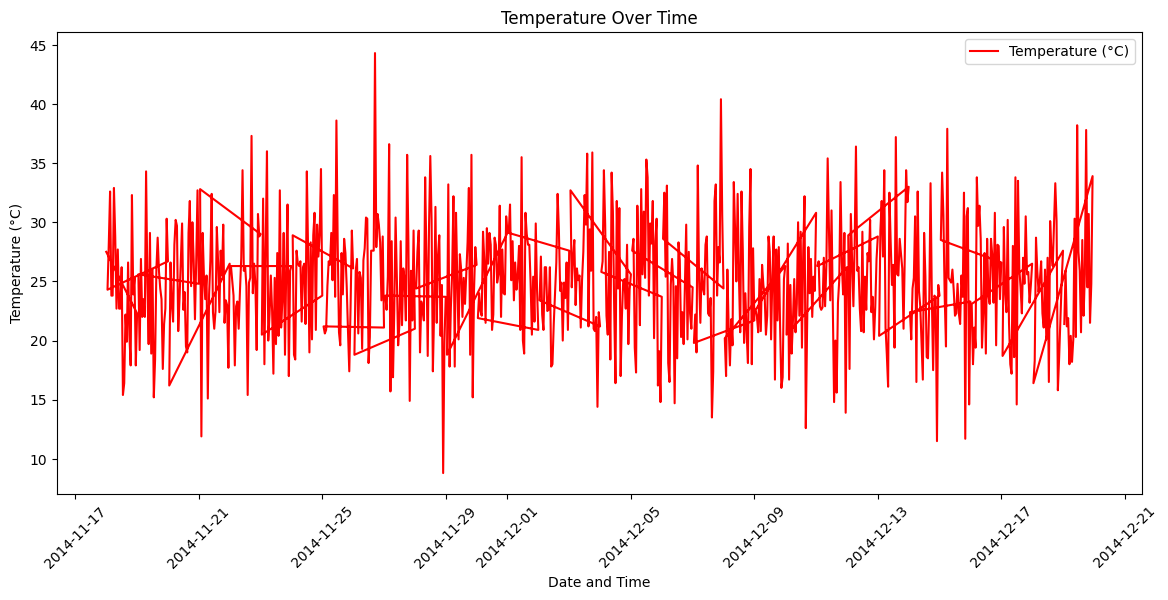

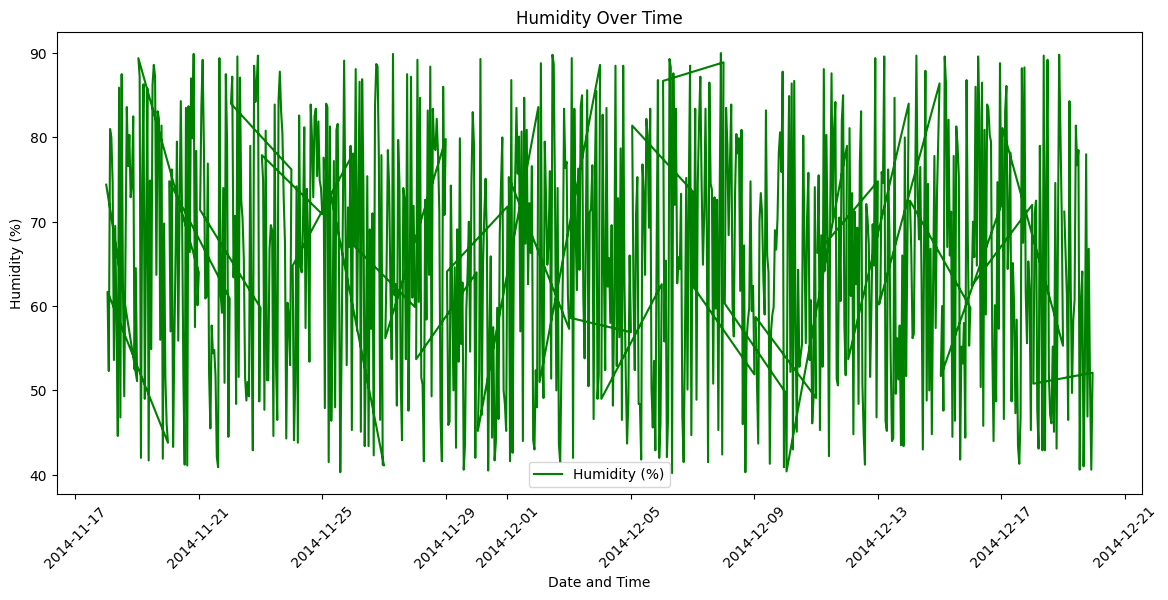

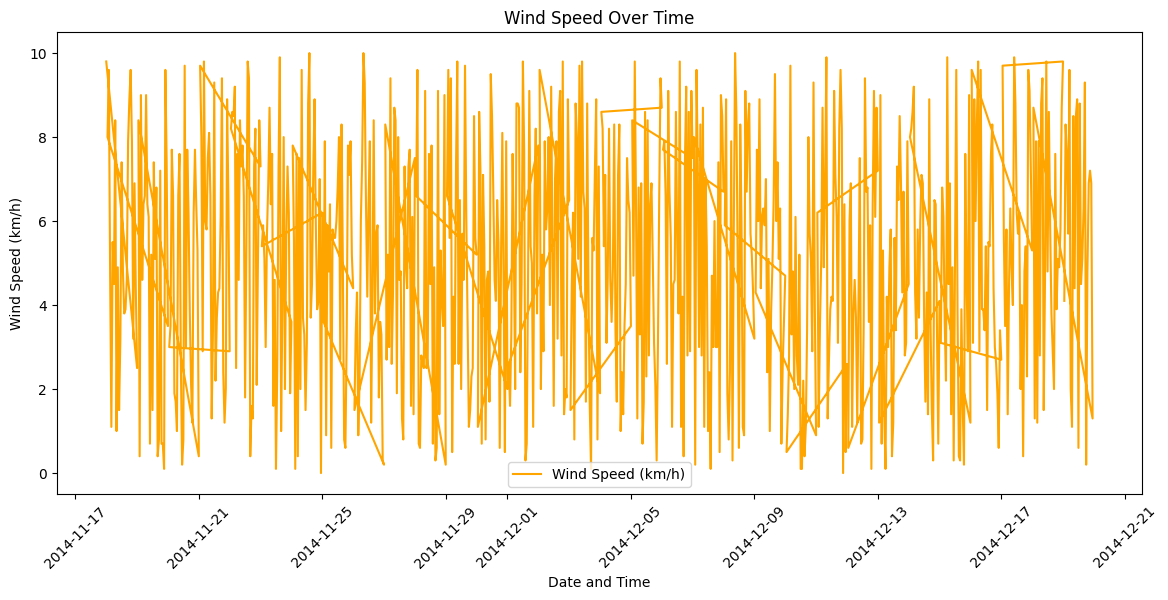

In [15]:
import matplotlib.pyplot as plt

# Convert 'datetime' to pandas datetime format for easier handling
merged_df['datetime'] = pd.to_datetime(merged_df['datetime'])

# Plot energy consumption over time
plt.figure(figsize=(14, 6))
plt.plot(merged_df['datetime'], merged_df['AEP_MW'], label='Energy Consumption (MW)', color='blue')
plt.xlabel('Date and Time')
plt.ylabel('Energy Consumption (MW)')
plt.title('Energy Consumption Over Time')
plt.xticks(rotation=45)
plt.legend()
plt.show()

# Plot temperature over time
plt.figure(figsize=(14, 6))
plt.plot(merged_df['datetime'], merged_df['temperature_C'], label='Temperature (°C)', color='red')
plt.xlabel('Date and Time')
plt.ylabel('Temperature (°C)')
plt.title('Temperature Over Time')
plt.xticks(rotation=45)
plt.legend()
plt.show()

# Plot humidity over time
plt.figure(figsize=(14, 6))
plt.plot(merged_df['datetime'], merged_df['humidity_%'], label='Humidity (%)', color='green')
plt.xlabel('Date and Time')
plt.ylabel('Humidity (%)')
plt.title('Humidity Over Time')
plt.xticks(rotation=45)
plt.legend()
plt.show()

# Plot wind speed over time
plt.figure(figsize=(14, 6))
plt.plot(merged_df['datetime'], merged_df['wind_speed_kmph'], label='Wind Speed (km/h)', color='orange')
plt.xlabel('Date and Time')
plt.ylabel('Wind Speed (km/h)')
plt.title('Wind Speed Over Time')
plt.xticks(rotation=45)
plt.legend()
plt.show()

                   AEP_MW  temperature_C  humidity_%  wind_speed_kmph
AEP_MW           1.000000      -0.005929    0.000714         0.023306
temperature_C   -0.005929       1.000000    0.032377        -0.017990
humidity_%       0.000714       0.032377    1.000000        -0.041086
wind_speed_kmph  0.023306      -0.017990   -0.041086         1.000000


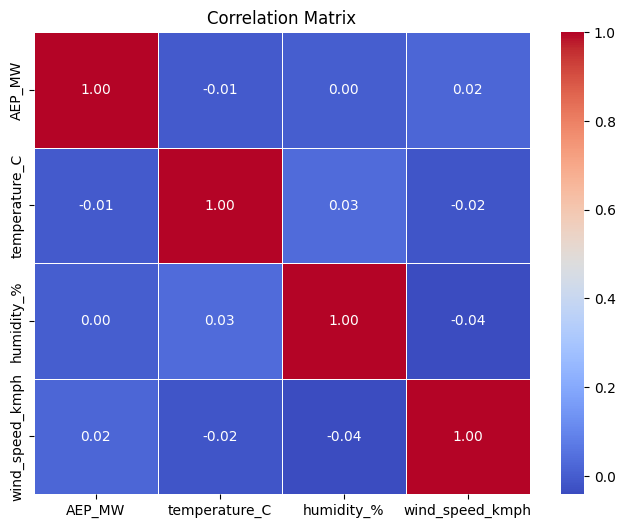

In [16]:
# Calculate the correlation between energy consumption and weather features
correlation_matrix = merged_df[['AEP_MW', 'temperature_C', 'humidity_%', 'wind_speed_kmph']].corr()

# Display the correlation matrix
print(correlation_matrix)

# Plot the correlation matrix
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Features and target variable
X = merged_df[['temperature_C', 'humidity_%', 'wind_speed_kmph']]
y = merged_df['AEP_MW']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the linear regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

Mean Squared Error: 3859052.054784457
R-squared: -0.005257451973232685


In [18]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f'Mean Squared Error (Random Forest): {mse_rf}')
print(f'R-squared (Random Forest): {r2_rf}')

Mean Squared Error (Random Forest): 4468348.602764285
R-squared (Random Forest): -0.16397515948871177


In [19]:
# Convert datetime to datetime object if not already
merged_df['datetime'] = pd.to_datetime(merged_df['datetime'])

# Feature engineering: Add hour, day of week, etc.
merged_df['hour'] = merged_df['datetime'].dt.hour
merged_df['dayofweek'] = merged_df['datetime'].dt.dayofweek
merged_df['month'] = merged_df['datetime'].dt.month

# Define features and target again
features = ['temperature_C', 'humidity_%', 'wind_speed_kmph', 'hour', 'dayofweek', 'month']
X = merged_df[features]
y = merged_df['AEP_MW']

In [20]:
# Split again
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit the model again
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'MSE: {mse}')
print(f'R2: {r2}')

MSE: 1643081.3425493503
R2: 0.5719882135955865


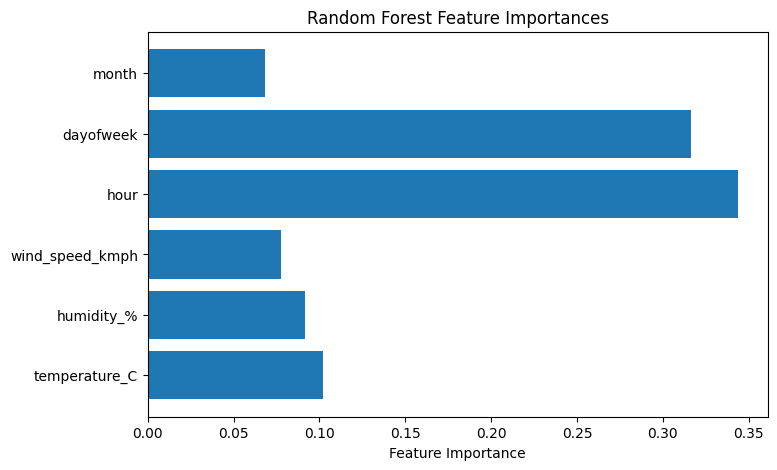

In [21]:
import matplotlib.pyplot as plt

# Get feature importances
importances = model.feature_importances_
feature_names = X.columns

# Plot
plt.figure(figsize=(8, 5))
plt.barh(feature_names, importances)
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importances")
plt.show()

In [1]:
# Ensure that datetime is set as index
merged_df['datetime'] = pd.to_datetime(merged_df['datetime'])
merged_df.set_index('datetime', inplace=True)

# Aggregate by hour or day if needed
time_series_data = merged_df['AEP_MW']

NameError: name 'pd' is not defined

In [2]:
from prophet import Prophet

# Prepare data for Prophet
prophet_df = merged_df[['AEP_MW']].reset_index().rename(columns={'datetime': 'ds', 'AEP_MW': 'y'})

# Initialize and fit the Prophet model
model_prophet = Prophet()
model_prophet.fit(prophet_df)

# Make future dataframe
future = model_prophet.make_future_dataframe(prophet_df, periods=12, freq='H')  # Adjust for hourly forecast
forecast_prophet = model_prophet.predict(future)

Importing plotly failed. Interactive plots will not work.


NameError: name 'merged_df' is not defined

In [3]:
# Make sure your datetime columns are in datetime format
ev_data['datetime'] = pd.to_datetime(ev_data['datetime'])
weather['datetime'] = pd.to_datetime(weather['datetime'])

# Merge the datasets on datetime
merged_df = pd.merge(ev_data, weather, on='datetime')

NameError: name 'pd' is not defined

In [1]:
prophet_df = merged_df[['datetime', 'AEP_MW']].rename(columns={'datetime': 'ds', 'AEP_MW': 'y'})

NameError: name 'merged_df' is not defined

In [2]:
import pandas as pd

# Load your datasets again if not already loaded
ev_data = pd.read_csv(r"C:\Users\Yashfeen Fatma\Downloads\AEP_hourly.csv")
weather = pd.read_csv(r"C:\Users\Yashfeen Fatma\Downloads\jamshedpur_weather_mock.csv")

# Ensure datetime column is in datetime format and rename if needed
ev_data.rename(columns={'Datetime': 'datetime'}, inplace=True)
ev_data['datetime'] = pd.to_datetime(ev_data['datetime'])
weather['datetime'] = pd.to_datetime(weather['datetime'])

# Merge
merged_df = pd.merge(ev_data, weather, on='datetime')

Importing plotly failed. Interactive plots will not work.
00:07:34 - cmdstanpy - INFO - Chain [1] start processing
00:07:35 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\Yashfeen Fatma\AppData\Local\Programs\Python\Python313\Lib\site-packages\prophet\forecaster.py:1854: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(


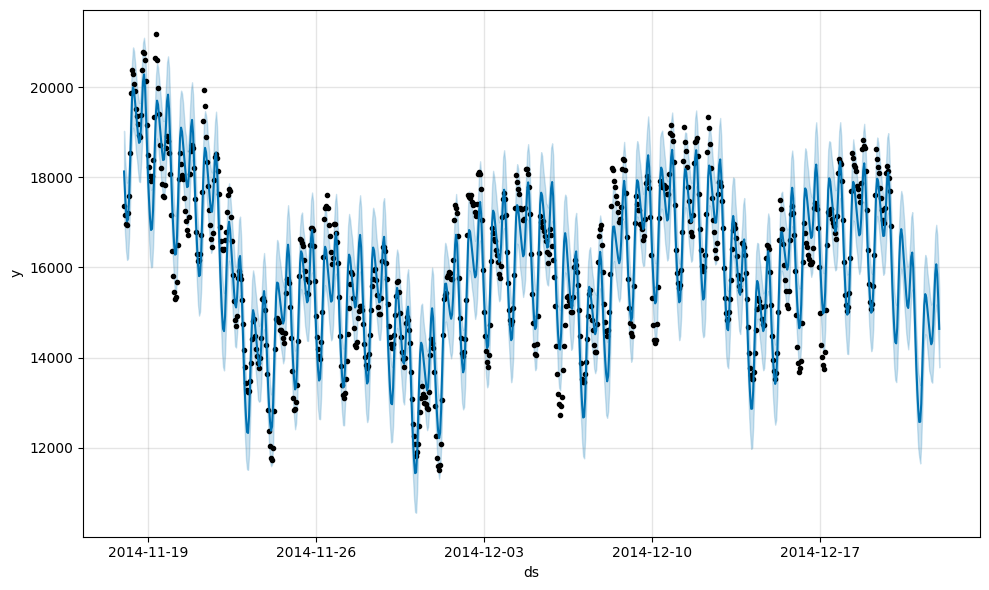

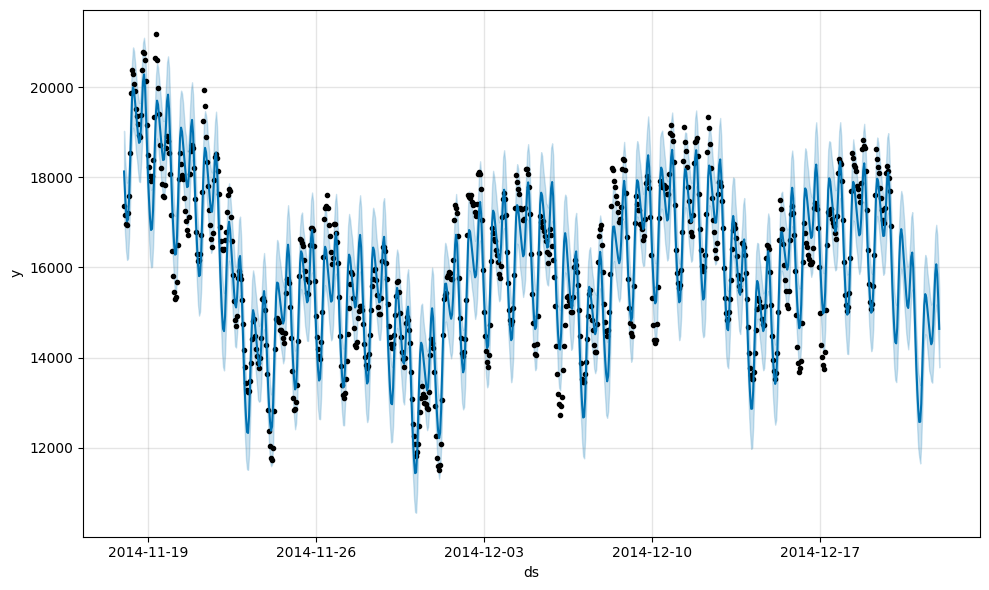

In [3]:
from prophet import Prophet

# Prepare for Prophet
prophet_df = merged_df[['datetime', 'AEP_MW']].rename(columns={'datetime': 'ds', 'AEP_MW': 'y'})

# Fit model
model_prophet = Prophet()
model_prophet.fit(prophet_df)

# Forecast
future = model_prophet.make_future_dataframe(periods=48, freq='H')
forecast = model_prophet.predict(future)

# Plot
model_prophet.plot(forecast)

In [4]:
forecast_output = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
forecast_output.to_csv("prophet_forecast_output.csv", index=False)

In [5]:
combined = pd.merge(prophet_df, forecast_output, left_on='ds', right_on='ds', how='left')
combined.to_csv("prophet_actual_vs_forecast.csv", index=False)

In [7]:
forecast_output.to_csv("prophet_forecast_output.csv", index=False)

In [8]:
import pandas as pd

forecast_data = pd.read_csv("prophet_forecast_output.csv")
print(forecast_data.head())

                    ds          yhat    yhat_lower    yhat_upper
0  2014-11-18 00:00:00  18128.670820  17285.025131  19030.689635
1  2014-11-18 01:00:00  17636.938517  16733.982116  18423.728567
2  2014-11-18 02:00:00  17252.908477  16366.373407  18096.818027
3  2014-11-18 03:00:00  17019.349842  16165.157061  17882.175270
4  2014-11-18 04:00:00  17066.026139  16200.243737  17961.768827


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(forecast_data['ds'], forecast_data['yhat'], label='Forecasted Demand', color='blue')
plt.fill_between(forecast_data['ds'], forecast_data['yhat_lower'], forecast_data['yhat_upper'], 
                 color='skyblue', alpha=0.3, label='Confidence Interval')
plt.xlabel('Date')
plt.ylabel('EV Demand (MW)')
plt.title('EV Charging Demand Forecast (Prophet)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [1]:
forecast_output = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
forecast_output.to_csv("prophet_forecast_output.csv", index=False)

NameError: name 'forecast' is not defined

In [4]:
import pandas as pd
from prophet import Prophet

In [5]:
# Assuming 'datetime' is your date column and 'AEP_MW' is your target variable
merged_df.rename(columns={'datetime': 'ds', 'AEP_MW': 'y'}, inplace=True)

# Ensure 'ds' column is in datetime format
merged_df['ds'] = pd.to_datetime(merged_df['ds'])

NameError: name 'merged_df' is not defined

In [7]:
import pandas as pd

In [8]:
# Load EV usage data
ev_df = pd.read_csv('ev_usage.csv')  # Replace with your actual file name

# Load weather data
weather_df = pd.read_csv('weather.csv')  # Replace with your actual file name

FileNotFoundError: [Errno 2] No such file or directory: 'ev_usage.csv'

In [1]:
import pandas as pd
import os

# Define the path to your Downloads folder
downloads_path = os.path.expanduser("~/Downloads")

# Construct full file paths
ev_path = os.path.join(downloads_path, "ev_demand_forecast.csv")
forecast_path = os.path.join(downloads_path, "prophet_forecast_output.csv")
output_path = os.path.join(downloads_path, "final_merged_ev_forecast.xlsx")

# Load the EV demand dataset
ev_df = pd.read_csv(ev_path, parse_dates=['datetime'])

# Load the Prophet forecast output and rename 'ds' to 'datetime'
forecast_df = pd.read_csv(forecast_path, parse_dates=['ds'])
forecast_df.rename(columns={'ds': 'datetime'}, inplace=True)

# Merge the two datasets on the 'datetime' column
merged_df = pd.merge(ev_df, forecast_df, on='datetime', how='inner')

# Save the merged dataset to an Excel file
merged_df.to_excel(output_path, index=False)

print(f"✅ Merge complete! File saved to: {output_path}")

✅ Merge complete! File saved to: C:\Users\Yashfeen Fatma/Downloads\final_merged_ev_forecast.xlsx
